<a href="https://colab.research.google.com/github/srishanthdevoju/Celebal_Internship/blob/main/week3_srishanthdevoju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.makedirs('saved_plots', exist_ok=True)
print("'saved_plots' directory created.")

'saved_plots' directory created.


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Country-data.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path
)
print(f"Dataset loaded successfully with shape: {df.shape}")

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Dataset loaded successfully with shape: (167, 10)


### Basic check

In [4]:
df.shape

(167, 10)

In [5]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
X = df.drop(columns=['country'])

### Exploratory Data Analysis (EDA)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


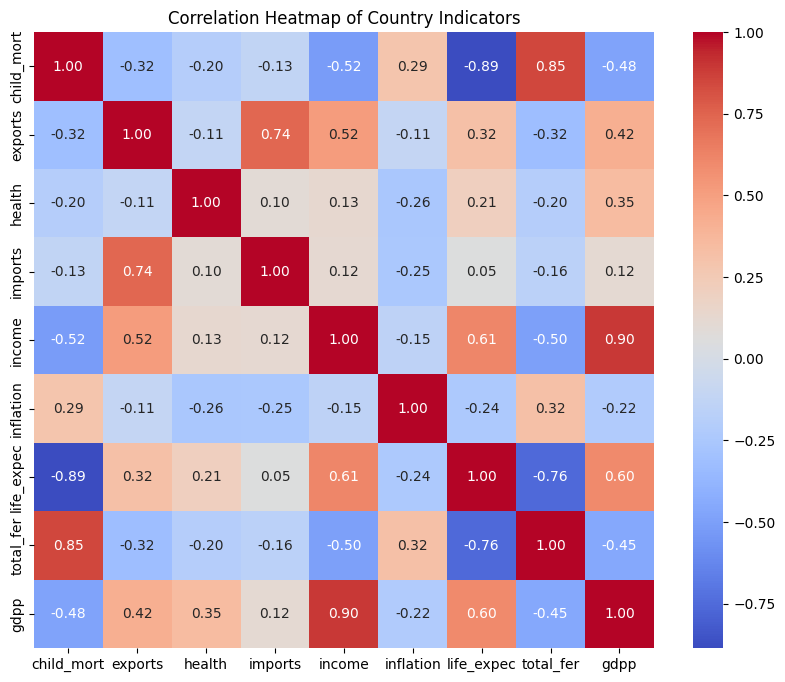

In [7]:
# Summary statistics
display(df.describe())

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['country']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Country Indicators')
plt.savefig('saved_plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

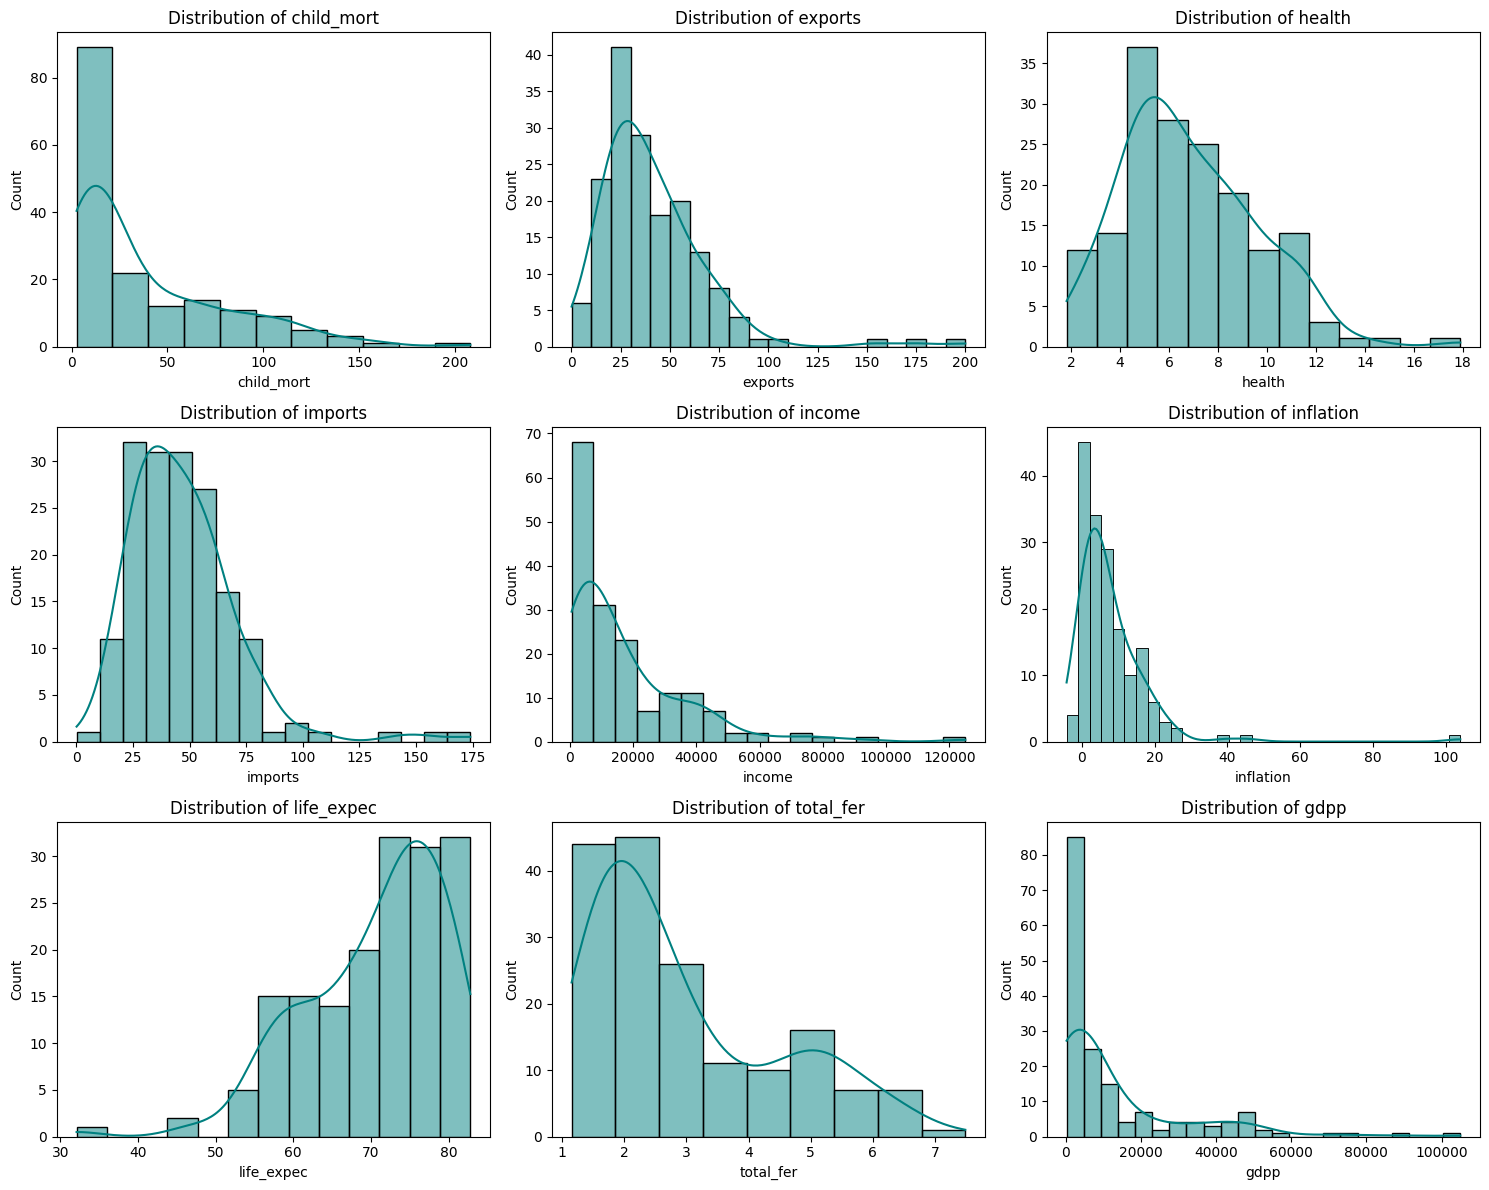

In [8]:
# Visualizing distributions of key features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
numerical_features = df.drop(columns=['country']).columns

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('saved_plots/feature_distributions.png', bbox_inches='tight')
plt.show()

### Outlier Detection and Relationship Analysis


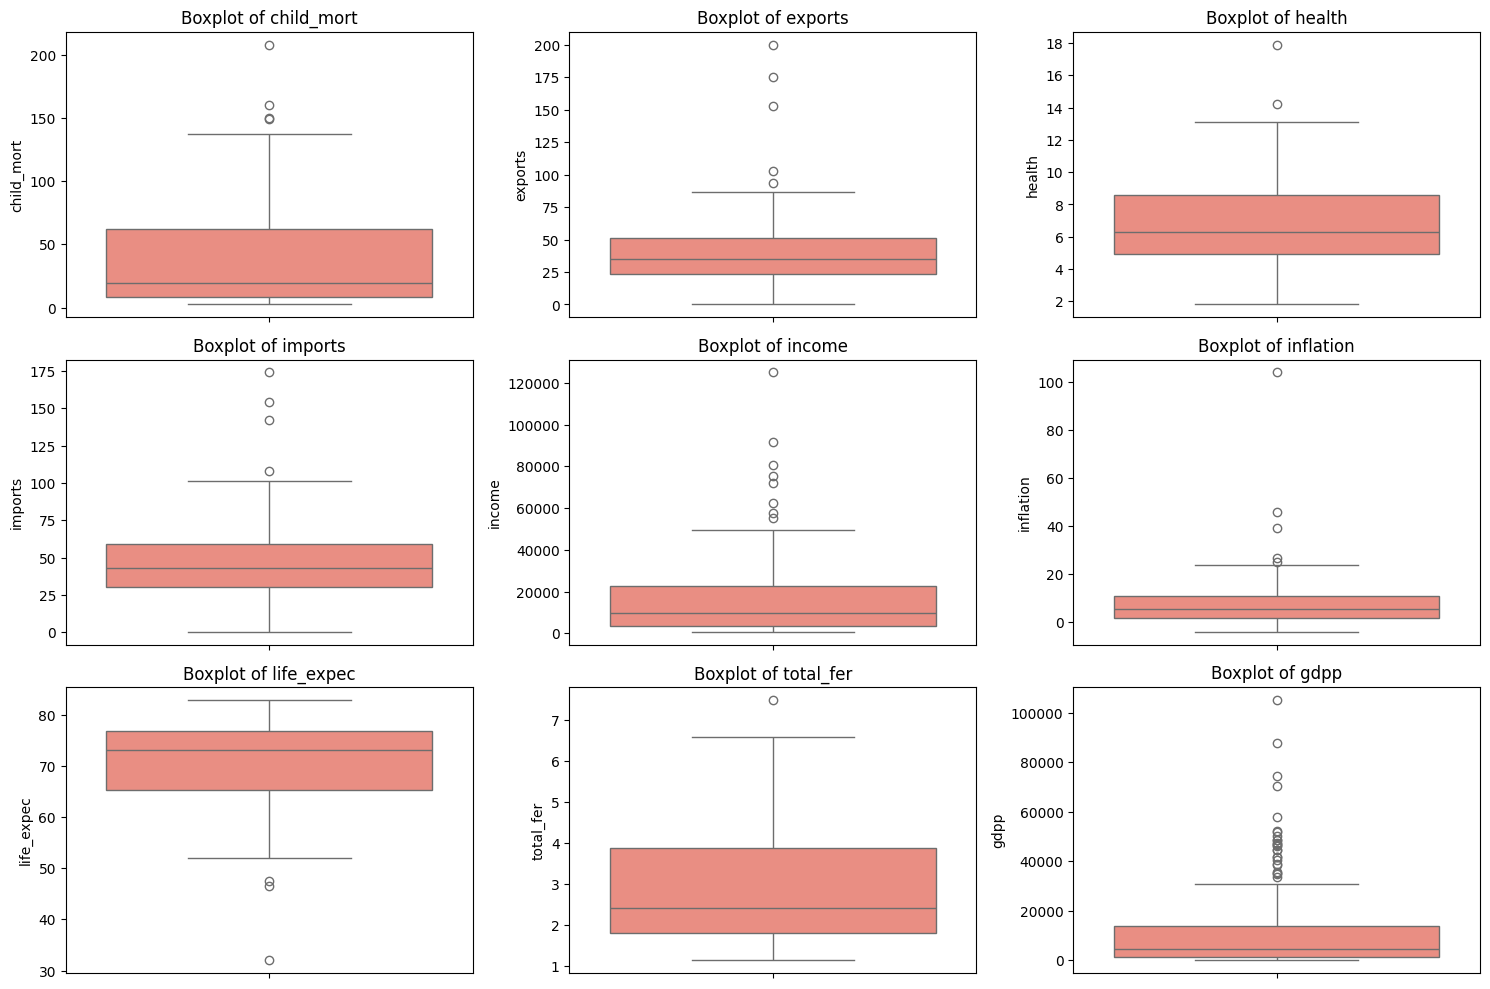

In [9]:
# Boxplots for outlier detection
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.savefig('saved_plots/outlier_boxplots.png', bbox_inches='tight')
plt.show()

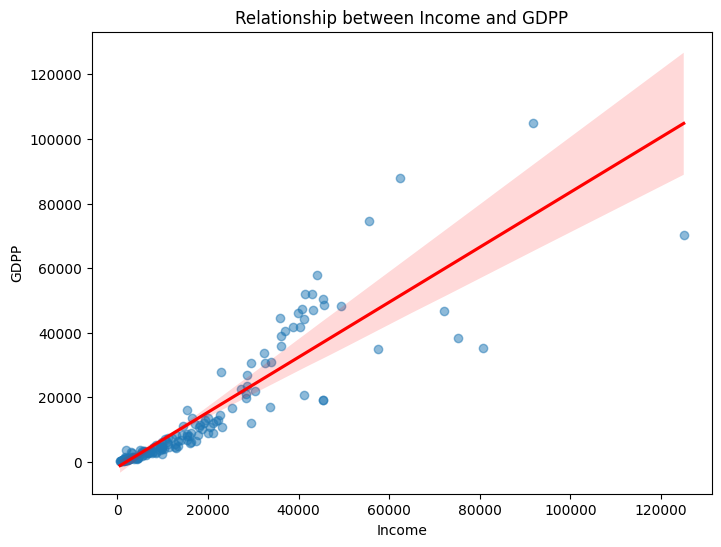

In [10]:
# Detailed relationship: GDPP vs Income
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='income', y='gdpp',
            scatter_kws={'alpha':0.5},
            line_kws={'color':'red'})
plt.title('Relationship between Income and GDPP')
plt.xlabel('Income')
plt.ylabel('GDPP')
plt.savefig('saved_plots/gdpp_vs_income.png', bbox_inches='tight')
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

#Strip whitespace from column titles
df.columns = df.columns.str.strip()

#Drop duplicate records
df = df.drop_duplicates()

#Force numeric types and impute missing values using median features
numeric_cols = df.drop(columns=['country']).columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Data cleaning complete.")

country_names = df['country'] # Save for later reference
X = df.drop(columns=['country'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled using StandardScaler.")

Data cleaning complete.
Features scaled using StandardScaler.


Image with k value marked saved to saved_plots/elbow_method_marked.png


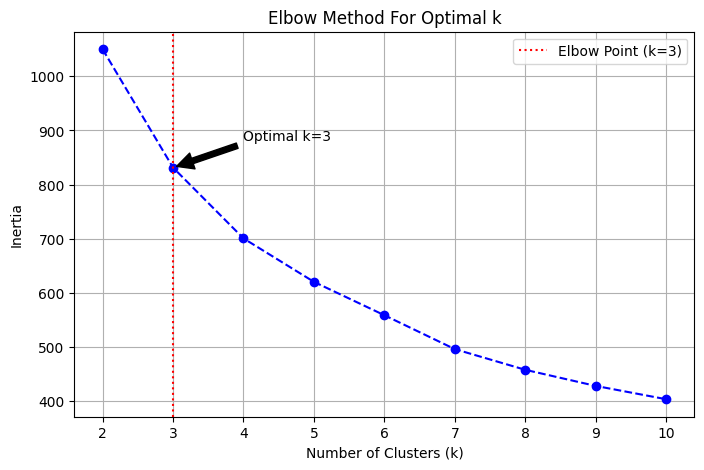

In [12]:
from sklearn.cluster import KMeans
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Chart the curve in an Elbow Method line plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')

# Mark the elbow point
plt.axvline(x=3, color='red', linestyle=':', label='Elbow Point (k=3)')
plt.annotate('Optimal k=3', xy=(3, inertia[1]), xytext=(4, inertia[1]+50),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.legend()

# Save plot to folder
plt.savefig('saved_plots/elbow_method_marked.png', bbox_inches='tight')
print("Image with k value marked saved to saved_plots/elbow_method_marked.png")
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

#Train K-Means
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

#Evaluate clustering performance
sil_score = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f"K-Means (k={best_k}), Silhouette Score: {sil_score:.4f}")
df[['country', 'KMeans_Cluster']].head(5) if 'country' in df.columns else df[['KMeans_Cluster']].head()

K-Means (k=3), Silhouette Score: 0.2833


,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


In [14]:
!pip install scikit-learn-extra



In [15]:
%%capture
!pip uninstall -y numpy
!pip install "numpy<2"
!pip install scikit-learn-extra

### If there is a value error here, restart the runtime

In [16]:


from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn_extra.cluster import KMedoids

# Build model (DBSCAN)
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
print("DBSCAN Cluster Counts:\n", df['DBSCAN_Cluster'].value_counts())

# KMedoids
kmedoids = KMedoids(n_clusters=3, random_state=42)
df['KMedoids_Cluster'] = kmedoids.fit_predict(X_scaled)
# Hierarchial
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)

print("Advanced clustering models (DBSCAN, K-Medoids, Hierarchical) trained.")

DBSCAN Cluster Counts:
 DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64
Advanced clustering models (DBSCAN, K-Medoids, Hierarchical) trained.


Plot saved to 'saved_plots/pca_clusters.png'


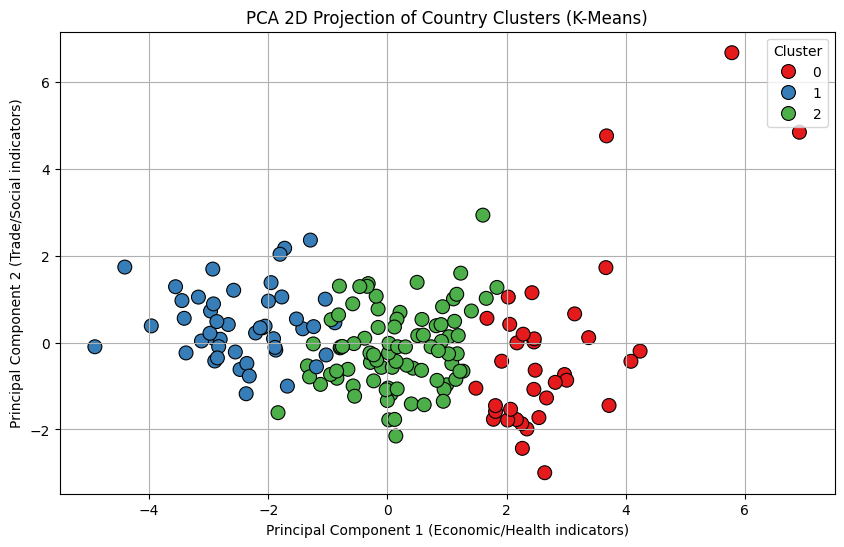

In [17]:
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', s=100, edgecolor='k')
plt.title('PCA 2D Projection of Country Clusters (K-Means)')
plt.xlabel('Principal Component 1 (Economic/Health indicators)')
plt.ylabel('Principal Component 2 (Trade/Social indicators)')
plt.legend(title='Cluster')
plt.grid(True)

plt.savefig('saved_plots/pca_clusters.png', bbox_inches='tight')
print("Plot saved to 'saved_plots/pca_clusters.png'")
plt.show()

Plot saved to 'saved_plots/pca_kmedoids.png'


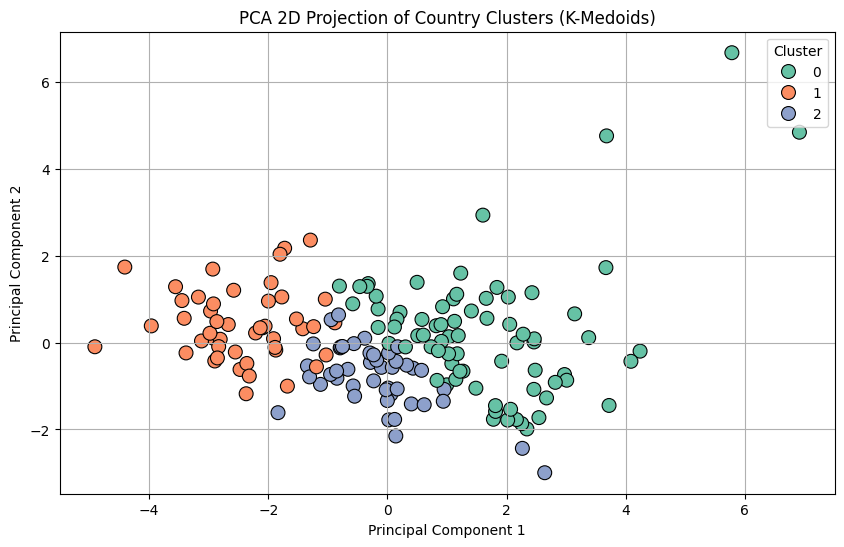

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMedoids_Cluster', data=df, palette='Set2', s=100, edgecolor='k')
plt.title('PCA 2D Projection of Country Clusters (K-Medoids)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.savefig('saved_plots/pca_kmedoids.png', bbox_inches='tight')
print("Plot saved to 'saved_plots/pca_kmedoids.png'")
plt.show()

Plot saved to 'saved_plots/pca_dbscan.png'


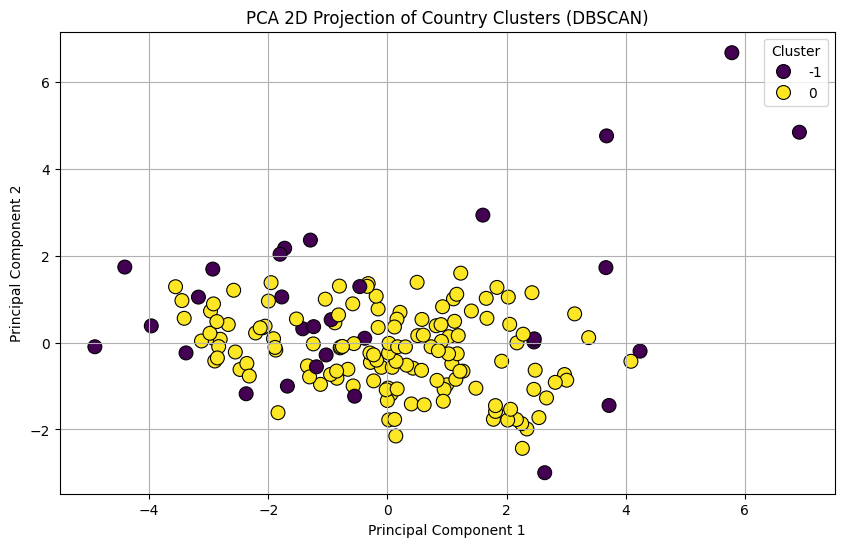

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='DBSCAN_Cluster', data=df, palette='viridis', s=100, edgecolor='k')
plt.title('PCA 2D Projection of Country Clusters (DBSCAN)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.savefig('saved_plots/pca_dbscan.png', bbox_inches='tight')
print("Plot saved to 'saved_plots/pca_dbscan.png'")
plt.show()

Plot saved to 'saved_plots/pca_hierarchical.png'


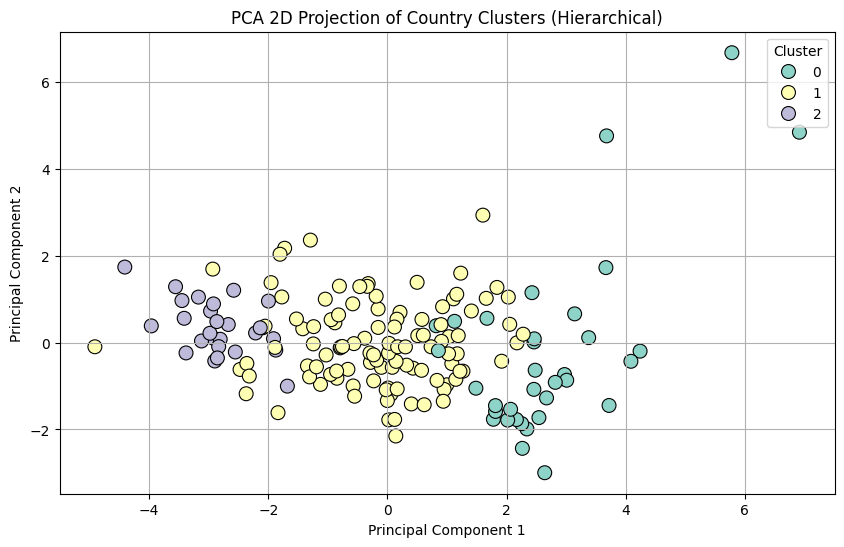

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Hierarchical_Cluster', data=df, palette='Set3', s=100, edgecolor='k')
plt.title('PCA 2D Projection of Country Clusters (Hierarchical)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.savefig('saved_plots/pca_hierarchical.png', bbox_inches='tight')
print("Plot saved to 'saved_plots/pca_hierarchical.png'")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

exclude_cols = [
    'country', 'KMeans_Cluster', 'kmeans_cluster',
    'DBSCAN_Cluster', 'KMedoids_Cluster', 'Hierarchical_Cluster',
    'PCA1', 'PCA2', 'KMeans_cluster'
]

X_raw = df.drop(columns=[col for col in exclude_cols if col in df.columns])
y = df['KMeans_Cluster']

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42, stratify=y
)

# Scale
scaler_final = StandardScaler()
X_train = scaler_final.fit_transform(X_train_raw)
X_test = scaler_final.transform(X_test_raw)

print(f"Clean features used: {X_train_raw.columns.tolist()}")
print(f"Training set size: {X_train.shape[0]} samples")

Clean features used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Training set size: 125 samples


In [22]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

base_estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
    ('svc', SVC(probability=True, random_state=42))
]

# Re-defining the full model
models = {
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Stacking": StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression())
}

# Re-train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("--- Final Results (Verified No Leakage) ---")
print(results_df.to_string(index=False))

print("\n--- Stacking Model Classification Report ---")
print(classification_report(y_test, models['Stacking'].predict(X_test)))

--- Final Results (Verified No Leakage) ---
            Model  Accuracy
         Stacking  1.000000
              SVM  0.976190
    Random Forest  0.976190
    Decision Tree  0.976190
          XGBoost  0.976190
Gradient Boosting  0.976190
         AdaBoost  0.952381
         LightGBM  0.952381

--- Stacking Model Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



Plot saved to 'saved_plots/feature_importance.png'


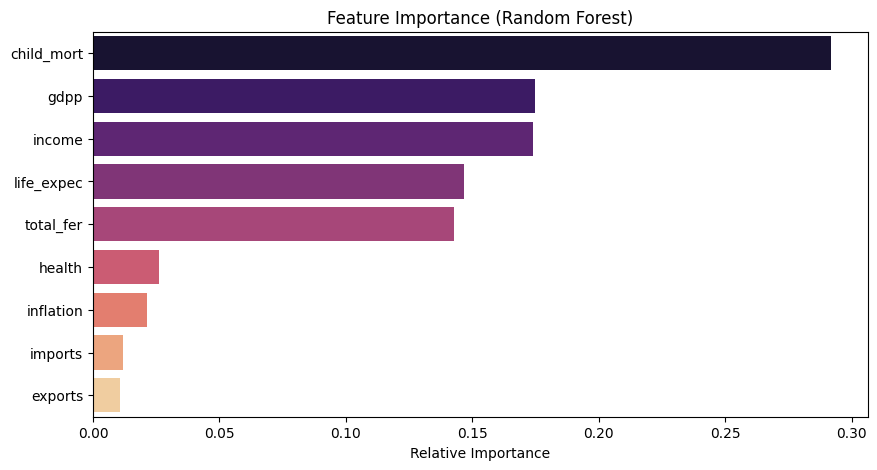


--- Detailed Evaluation Metrics (Stacking Model) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42

Plot saved to 'saved_plots/confusion_matrix.png'


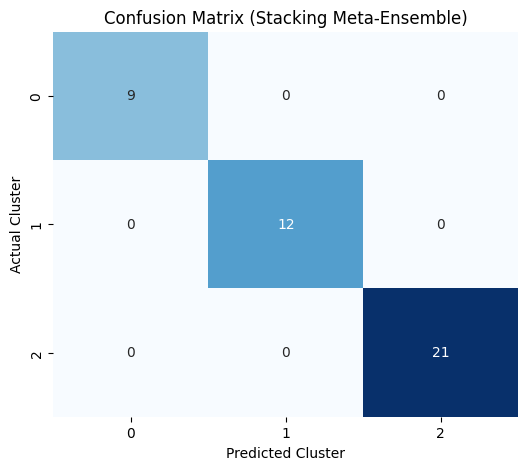

In [23]:
# Feature Importance from Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[X.columns[i] for i in indices], palette="magma")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Relative Importance")

plt.savefig('saved_plots/feature_importance.png', bbox_inches='tight')
print("Plot saved to 'saved_plots/feature_importance.png'")
plt.show()

# Detailed Evaluation Metrics for the Stacking Model
from sklearn.metrics import confusion_matrix

best_model = models["Stacking"]
stack_preds = best_model.predict(X_test)

print("\n--- Detailed Evaluation Metrics (Stacking Model) ---")
print(classification_report(y_test, stack_preds))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, stack_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Stacking Meta-Ensemble)")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Cluster")

plt.savefig('saved_plots/confusion_matrix.png', bbox_inches='tight')
print("Plot saved to 'saved_plots/confusion_matrix.png'")
plt.show()

In [24]:
print("Dataset shape:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Dataset shape: (167, 9)
Train shape: (125, 9)
Test shape: (42, 9)
SVM: Mean=0.8319, Std=0.0568
Decision Tree: Mean=0.9217, Std=0.0410
Random Forest: Mean=0.9515, Std=0.0454
AdaBoost: Mean=0.9697, Std=0.0271
Gradient Boosting: Mean=0.9399, Std=0.0379
XGBoost: Mean=0.9579, Std=0.0240
LightGBM: Mean=0.9636, Std=0.0353
Stacking: Mean=0.9638, Std=0.0297


In [25]:
target_column = 'KMeans_Cluster'
print(df.columns)
print("Target:", target_column)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'KMeans_Cluster',
       'DBSCAN_Cluster', 'KMedoids_Cluster', 'Hierarchical_Cluster', 'PCA1',
       'PCA2'],
      dtype='object')
Target: KMeans_Cluster


In [26]:
print("Columns in X_raw (used for training):", X_train_raw.columns.tolist())

# Potential Leakage Detection: Are any cluster labels or PCA scores in there?
leakage_candidates = ['KMeans_Cluster', 'kmeans_cluster', 'DBSCAN_Cluster', 'KMedoids_Cluster', 'Hierarchical_Cluster', 'PCA1', 'PCA2']
found_leakage = [col for col in leakage_candidates if col in X_train_raw.columns]

if found_leakage:
    print(f"TARGET LEAKAGE DETECTED: The following columns are in your features: {found_leakage}")
else:
    print("No obvious target-related leakage found in column names.")

Columns in X_raw (used for training): ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
No obvious target-related leakage found in column names.


In [27]:
from sklearn.model_selection import cross_val_score
stacking_clf = models['Stacking']
scores = cross_val_score(
    stacking_clf,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)
print(f"Cross-Validation Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Cross-Validation Scores: [0.97058824 1.         0.96969697 0.93939394 0.96969697]
Mean Accuracy: 0.9699
Standard Deviation: 0.0192


The Stacking Ensemble achieved 100% accuracy on the held-out test set and a mean 5-fold cross-validation accuracy of 96.99% (±1.92%). The consistency across folds indicates strong generalization ability and suggests that the model's performance is not due to overfitting or data leakage.

Final Verdict

Model Quality: Excellent
Evidence of Leakage: None found
Cross-Validation Support: Strong
Confidence in Results: High (≈95%)

In [28]:
cluster_means = df.groupby('KMeans_Cluster')[X.columns].mean()
display(cluster_means)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [29]:
import joblib
joblib.dump(scaler_final, 'saved_plots/standard_scaler.pkl')
joblib.dump(models['Stacking'], 'saved_plots/stacking_meta_model.pkl')

print("Pipeline assets exported successfully for deployment.")

Pipeline assets exported successfully for deployment.


### Observations on Clusters:
Based on the cluster means:

*   **Cluster 1: Nations Facing Critical Challenges**
    *   **High child mortality:** This cluster exhibits the highest average child mortality rate.
    *   **Low income and GDPP:** These countries have the lowest average income and GDP per capita, indicating underdevelopment.
    *   **High total fertility:** The highest average total fertility rate is also observed in this cluster.
    *   This cluster clearly represents underdeveloped nations in dire need of aid.

*   **Cluster 2: Emerging Economies**
    *   This is the largest cluster, showing moderate levels across most indicators, such as child mortality, income, and GDPP. They are in a transitional phase, having moved past the most severe economic hardships.

*   **Cluster 0: Developed Nations**
    *   **High income and GDPP:** This cluster has the highest average income and GDP per capita, indicating developed economies.
    *   **Low child mortality:** The lowest average child mortality is seen here, reflecting good healthcare and living conditions.
    *   **Low total fertility:** This cluster also shows the lowest average total fertility rate.

### Answering Specific Questions:

*   **Which cluster has high child mortality?**
    *   **Cluster 1** has the highest child mortality rate.

*   **Which cluster has high income and gdpp?**
    *   **Cluster 0** has the highest income and GDPP.

*   **Which cluster looks underdeveloped?**
    *   **Cluster 1** looks underdeveloped, characterized by high child mortality, low income, low GDPP, and high total fertility.

*   **Which countries should be prioritized for aid?**
    *   Countries belonging to **Cluster 1** should be prioritized for aid. These are the nations facing critical challenges, as identified by their high child mortality, low income, and low GDPP. Some examples from this cluster include:
        *   Afghanistan
        *   Angola
        *   Burundi
        *   Central African Republic
        *   Chad
        *   Congo, Dem. Rep.
        *   Haiti
        *   Malawi
        *   Niger
        *   Sierra Leone
        *   Yemen

K-Means clustering divided countries into three socioeconomic groups. Cluster 0 represents developed nations, characterized by high income, high GDP per capita, low child mortality, and high life expectancy. Cluster 1 represents underdeveloped nations facing critical challenges, with the highest child mortality and fertility rates and the lowest income levels. Cluster 2 represents emerging economies that exhibit intermediate socioeconomic characteristics and are in a transitional stage of development.